# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2383 Борисов Иван Вадимович и Сыздыков Нургалым Конакбаевич. Вариант №25

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи. 

## Краткое изложение основных теоретических понятий

### Метод наименьших квадратов

Регрессионный анализ направлен на установление аналитической формы зависимости между случайными величинами X и Y. Параметры выбранной функции регрессии определяются методом наименьших квадратов, суть которого заключается в минимизации суммы квадратов отклонений фактических значений зависимой переменной от их расчетных значений:
$$
S = \sum_{i=1}^n (y_i - \hat {y}_i)^2
$$

где $y_i$ $-$ наблюдаемое значение, $\hat {y}_i$ $-$ значение, предсказанное моделью.

### Выборочные прямые среднеквадратической регрессии

Если предполагается наличие линейной связи, строятся две прямые регрессии:
- Регрессия Y на X: $\overline{y}_x = \overline{y}_в + \rho_{yx} (x - \overline{x}_в)$
- Регрессия X на Y: $\overline{x}_y = \overline{x}_в + \rho_{xy} (y - \overline{y}_в)$
  
где $\rho_{yx} = \overline{r}_{xy} \frac{\sigma_y}{\sigma_x}$ и $\rho_{xy} = \overline{r}_{xy} \frac{\sigma_x}{\sigma_y}$ $-$ выборочные коэффициенты регрессии. Прямые всегда пересекаются в точке $(\overline{x}_в, \overline{y}_в)$.

### Выборочное корреляционное отношение

Корреляционное отношение является мерой тесноты произвольной зависимости. Оно рассчитывается через межгрупповую дисперсию:
$$
\eta = \frac{\sigma_{\overline{y}_x}}{\sigma_y}
$$

Свойства $\eta$:
- $0 \le \eta \le 1$;
- $\eta \ge |r_{xy}|$;
- если $\eta = |r_{xy}|$, то зависимость между величинами строго линейная.

### Нелинейные модели регрессии

Для описания более сложных зависимостей используются:
- Параболическая функция: $y = \beta_0 + \beta_1 x + \beta_2 x^2$. Параметры находятся путем решения системы нормальных уравнений.
- Степенная функция: $ y = \beta_0 x^{\beta_1}$. Для нахождения параметров применяется метод линеаризации (логарифмирование обеих частей):
$$
\ln{y} = \ln{\beta_0} + \beta_1 \ln{x}
$$

## Постановка задачи с кратким описанием порядка выполнения работы

Для заданной двумерной выборки (X,Y) построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать. 

### Порядок выполнения работы

1. Отобразить двумерную выборку на графике.
2. Для заданной выборки построить уравнения средней квадратичной регрессии x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.
3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \ge |r_{xy}|$ и $\eta_{yx} \ge |r_{xy}|$ выполняются.
4. Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.
5. Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы: a) степенная функция: $y = \beta_0 x^{\beta_1}$.

### 1. Отобразить двумерную выборку на графике.

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

In [12]:
df = pd.read_csv('Syzdykov_Borisov_data_116.csv')
N = len(df)

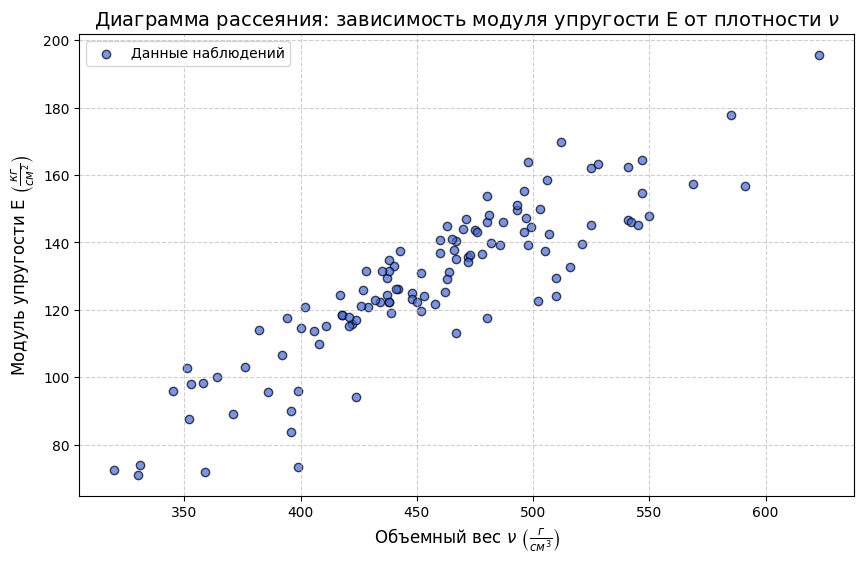

In [17]:
plt.rcdefaults()
plt.figure(figsize=(10, 6))
plt.scatter(df['nu'], df['E'], color='royalblue', alpha=0.7, edgecolors='k', label='Данные наблюдений')

plt.title(r'Диаграмма рассеяния: зависимость модуля упругости E от плотности $\nu$', fontsize=14)
plt.xlabel(r'Объемный вес $\nu$ $\left(\frac{г}{см^3}\right)$', fontsize=12)
plt.ylabel(r'Модуль упругости E $\left(\frac{кг}{см^2}\right)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

### 2. Для заданной выборки построить уравнения средней квадратичной регрессии x на y и y на x соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

In [18]:
def get_interval_stats(series: pd.Series) -> tuple[np.ndarray, np.ndarray, float, float]:
    n: int = len(series)
    k: int = int(np.ceil(1 + 3.31 * np.log10(n)))

    x_min: float = series.min()
    x_max: float = series.max()
    h: float = (x_max - x_min) / k

    bins: np.ndarray = np.linspace(x_min, x_max, k + 1)
    counts, edges = np.histogram(series, bins=bins)
    midpoints: np.ndarray = (edges[:-1] + edges[1:]) / 2

    return midpoints, counts, h, x_min

In [19]:
def create_table_1(midpoints: np.ndarray, counts: np.ndarray, h: float, label: str) -> tuple[pd.DataFrame, float, float]:
    """Формирование расчетной таблицы №1 с проверкой контроля."""
    max_idx: int = np.argmax(counts)
    C: float = midpoints[max_idx]

    # Расчет условных вариант
    u: np.ndarray = np.round((midpoints - C) / h).astype(int)

    n_u: np.ndarray = counts * u
    n_u2: np.ndarray = counts * (u**2)
    n_u3: np.ndarray = counts * (u**3)
    n_u4: np.ndarray = counts * (u**4)
    n_u_plus_1_4: np.ndarray = counts * ((u + 1)**4)

    df_t1: pd.DataFrame = pd.DataFrame({
        r'$i$': range(1, len(midpoints) + 1),
        r'$x_i$': midpoints,
        r'$n_i$': counts,
        r'$u_i$': u,
        r'$n_i \cdot u_i$': n_u,
        r'$n_i \cdot u_i^2$': n_u2,
        r'$n_i \cdot u_i^3$': n_u3,
        r'$n_i \cdot u_i^4$': n_u4,
        r'$n_i \cdot (u_i+1)^4$': n_u_plus_1_4
    })

    sums: dict = df_t1.sum()
    sum_row: pd.DataFrame = pd.DataFrame([{
        '$i$': r'$\Sigma$', r'$x_i$': np.nan, r'$n_i$': sums[r'$n_i$'], r'$u_i$': np.nan,
         r'$n_i \cdot u_i$': sums[r'$n_i \cdot u_i$'], r'$n_i \cdot u_i^2$': sums[r'$n_i \cdot u_i^2$'],
         r'$n_i \cdot u_i^3$': sums[r'$n_i \cdot u_i^3$'], r'$n_i \cdot u_i^4$': sums[r'$n_i \cdot u_i^4$'],
         r'$n_i \cdot (u_i+1)^4$': sums[r'$n_i \cdot (u_i+1)^4$']
    }])

    lhs: float = sums[r'$n_i \cdot (u_i+1)^4$']
    rhs: float = (sums[r'$n_i \cdot u_i^4$'] + 4*sums[r'$n_i \cdot u_i^3$'] + 6*sums[r'$n_i \cdot u_i^2$'] + 4*sums[r'$n_i \cdot u_i$'] + sums[r'$n_i$'])

    print(f"--- Контроль вычислений для {label} ---")
    display(Markdown(rf"$\sum n_i (u_i+1)^4 = {lhs}$"))
    display(Markdown(rf"$\sum n_i \cdot u_i^4 + 4 \sum n_i \cdot u_i^3 + 6 \sum n_i \cdot u_i^2 + 4 \sum n_i \cdot u_i + N = {rhs}$"))
    print(rf"Контроль пройден: {np.isclose(lhs, rhs)}")

    return pd.concat([df_t1, sum_row], ignore_index=True), C, h

In [20]:
def calculate_moments(table1: pd.DataFrame, h: float) -> pd.DataFrame:
    """Вычисление условных и центральных моментов."""
    row_sum: pd.Series = table1.iloc[-1]
    n: float = row_sum[r'$n_i$']

    # Условные моменты
    M1_star: float = row_sum[r'$n_i \cdot u_i$'] / n
    M2_star: float = row_sum[r'$n_i \cdot u_i^2$'] / n
    M3_star: float = row_sum[r'$n_i \cdot u_i^3$'] / n
    M4_star: float = row_sum[r'$n_i \cdot u_i^4$'] / n

    # Центральные моменты (через условные)
    m1: float = 0.0
    m2: float = (M2_star - M1_star**2) * (h**2)
    m3: float = (M3_star - 3*M1_star*M2_star + 2*M1_star**3) * (h**3)
    m4: float = (M4_star - 4*M1_star*M3_star + 6*M1_star**2*M2_star - 3*M1_star**4) * (h**4)

    return pd.DataFrame({
        r'$k$': [1, 2, 3, 4],
        r'$\overline{M}^*_k$': [M1_star, M2_star, M3_star, M4_star],
        r'$\overline{m}_k$': [m1, m2, m3, m4]
    })

In [21]:
def compute_main_stats(midpoints: np.ndarray, counts: np.ndarray, moments: pd.DataFrame, C: float, h: float, label: str) -> tuple[float, float, float]:
    """Сравнение методов расчета внутри интервального ряда."""
    # 1. Метод условных вариант
    m1_star: float = moments.loc[0, r'$\overline{M}^*_k$']
    x_avg_cond: float = m1_star * h + C
    d_v_cond: float = moments.loc[1, r'$\overline{m}_k$']

    # 2. Стандартная формула для интервального ряда
    x_avg_int: float = np.average(midpoints, weights=counts)
    d_v_int: float = np.average((midpoints - x_avg_int)**2, weights=counts)

    # 3. Выборочное СКО
    sigma_v: float = np.sqrt(d_v_cond)

    display(Markdown(f"#### Результаты для {label}:"))

    comparison_df: pd.DataFrame = pd.DataFrame({
        "Показатель": ["Среднее значение", "Выборочная дисперсия"],
        "Стандартная формула": [x_avg_int, d_v_int],
        "Условные варианты": [x_avg_cond, d_v_cond],
        "Разность": [abs(x_avg_int - x_avg_cond), abs(d_v_int - d_v_cond)]
    })
    display(comparison_df)

    display(Markdown(rf"Выборочное СКО ($\sigma_в$): **{sigma_v:.4f}**"))
    return x_avg_cond, d_v_cond, sigma_v

In [22]:
def build_bivariate_series_intervals(df, col_x, col_y):
    def get_bins(series):
        n = len(series)
        k = int(np.ceil(1 + 3.31 * np.log10(n)))
        return np.linspace(series.min(), series.max(), k + 1)

    bins_x = get_bins(df[col_x])
    bins_y = get_bins(df[col_y])

    labels_x = [f"[{bins_x[i]:.2f}, {bins_x[i+1]:.2f})" for i in range(len(bins_x)-2)]
    labels_x.append(f"[{bins_x[-2]:.2f}, {bins_x[-1]:.2f}]")
    
    labels_y = [f"[{bins_y[i]:.2f}, {bins_y[i+1]:.2f})" for i in range(len(bins_y)-2)]
    labels_y.append(f"[{bins_y[-2]:.2f}, {bins_y[-1]:.2f}]")

    x_intervals = pd.cut(df[col_x], bins=bins_x, labels=labels_x, include_lowest=True)
    y_intervals = pd.cut(df[col_y], bins=bins_y, labels=labels_y, include_lowest=True)

    return x_intervals, y_intervals

col_x = 'nu'
col_y = 'E'
x_intervals, y_intervals = build_bivariate_series_intervals(df, col_x, col_y)
bivariate_table = pd.crosstab(
    x_intervals, 
    y_intervals, 
    dropna=False,
    rownames=[f'Признак {col_x}'], 
    colnames=[f'Признак {col_y}']
)

print("Двумерный интервальный вариационный ряд:")
display(bivariate_table)

Двумерный интервальный вариационный ряд:


Признак E,"[71.10, 86.67)","[86.67, 102.25)","[102.25, 117.82)","[117.82, 133.40)","[133.40, 148.97)","[148.97, 164.55)","[164.55, 180.12)","[180.12, 195.70]"
Признак nu,,,,,,,,
"[320.00, 357.88)",3,3,1,0,0,0,0,0
"[357.88, 395.75)",1,4,4,0,0,0,0,0
"[395.75, 433.62)",2,3,8,9,0,0,0,0
"[433.62, 471.50)",0,0,1,21,11,0,0,0
"[471.50, 509.38)",0,0,1,1,17,7,0,0
"[509.38, 547.25)",0,0,0,3,5,5,1,0
"[547.25, 585.12)",0,0,0,0,1,1,1,0
"[585.12, 623.00]",0,0,0,0,0,1,0,1


--- Контроль вычислений для nu ---


$\sum n_i (u_i+1)^4 = 3722.0$

$\sum n_i \cdot u_i^4 + 4 \sum n_i \cdot u_i^3 + 6 \sum n_i \cdot u_i^2 + 4 \sum n_i \cdot u_i + N = 3722.0$

Контроль пройден: True


#### Результаты для nu:

...

$\sum n_i \cdot u_i^4 + 4 \sum n_i \cdot u_i^3 + 6 \sum n_i \cdot u_i^2 + 4 \sum n_i \cdot u_i + N = 2955.0$

Контроль пройден: True


#### Результаты для E:

,Показатель,Стандартная формула,Условные варианты,Разность
0,Среднее значение,128.163578,128.163578,0.000000e+00
1,Выборочная дисперсия,480.744465,480.744465,1.136868e-13


Выборочное СКО ($\sigma_в$): **21.9259**

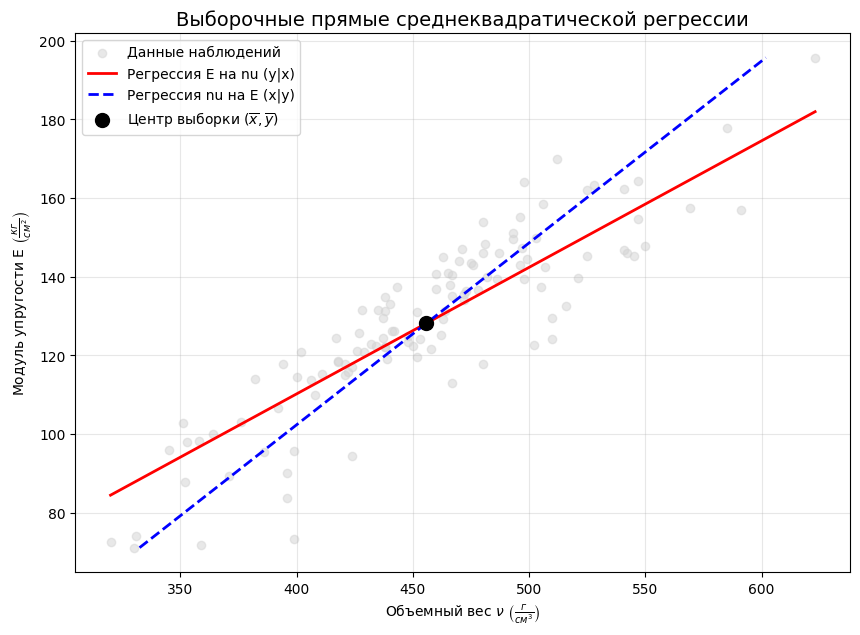

Уравнение регрессии Y на X: $E = 128.1636 + 0.3218 \cdot (\nu - 455.8276)$

Уравнение регрессии X на Y: $\nu = 455.8276 + 2.1618 \cdot (E - 128.1636)$

In [26]:
# Расчет параметров для nu (X)
mid_nu, counts_nu, h_nu_val, _ = get_interval_stats(df['nu'])
table1_nu, C_nu, h_nu_final = create_table_1(mid_nu, counts_nu, h_nu_val, "nu")
# Получаем x_nu и sigma_nu [cite: 316, 325]
x_nu, _, sigma_nu = compute_main_stats(mid_nu, counts_nu, calculate_moments(table1_nu, h_nu_final), C_nu, h_nu_final, "nu")

# Расчет параметров для E (Y)
mid_e, counts_e, h_e_val, _ = get_interval_stats(df['E'])
table1_e, C_e, h_e_final = create_table_1(mid_e, counts_e, h_e_val, "E")
# Получаем x_e и sigma_e [cite: 316, 325]
x_e, _, sigma_e = compute_main_stats(mid_e, counts_e, calculate_moments(table1_e, h_e_final), C_e, h_e_final, "E")

# Расчет коэффициента корреляции r_standard [cite: 711]
x_intervals, y_intervals = build_bivariate_series_intervals(df, 'nu', 'E')
correlation_table = pd.crosstab(x_intervals, y_intervals, dropna=False)
n_ij = correlation_table.values

sum_n_x_y = 0
for i in range(len(mid_nu)):
    for j in range(len(mid_e)):
        sum_n_x_y += n_ij[i, j] * mid_nu[i] * mid_e[j]

r_standard = (sum_n_x_y - N * x_nu * x_e) / (N * sigma_nu * sigma_e)

rho_yx = r_standard * (sigma_e / sigma_nu)
rho_xy = r_standard * (sigma_nu / sigma_e)

def regression_y_on_x(x):
    return x_e + rho_yx * (x - x_nu)

def regression_x_on_y(y):
    return x_nu + rho_xy * (y - x_e)

plt.figure(figsize=(10, 7))
plt.scatter(df['nu'], df['E'], color='lightgray', alpha=0.5, label='Данные наблюдений')

# Прямая регрессии Y на X
x_range = np.linspace(df['nu'].min(), df['nu'].max(), 100)
plt.plot(x_range, regression_y_on_x(x_range), color='red', linewidth=2, label=f'Регрессия E на nu (y|x)')

# Прямая регрессии X на Y
y_range = np.linspace(df['E'].min(), df['E'].max(), 100)
plt.plot(regression_x_on_y(y_range), y_range, color='blue', linestyle='--', linewidth=2, label=f'Регрессия nu на E (x|y)')

# Точка центра распределения
plt.scatter([x_nu], [x_e], color='black', s=100, zorder=5, label=r'Центр выборки ($\overline{x}, \overline{y}$)')

plt.title(r'Выборочные прямые среднеквадратической регрессии', fontsize=14)
plt.xlabel(r'Объемный вес $\nu$ $\left(\frac{г}{см^3}\right)$')
plt.ylabel(r'Модуль упругости E $\left(\frac{кг}{см^2}\right)$')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

display(Markdown((rf"Уравнение регрессии Y на X: $E = {x_e:.4f} + {rho_yx:.4f} \cdot (\nu - {x_nu:.4f})$")))
display(Markdown((rf"Уравнение регрессии X на Y: $\nu = {x_nu:.4f} + {rho_xy:.4f} \cdot (E - {x_e:.4f})$")))

- Пересечение: Прямые пересекаются точно в точке ($\overline{x}_в \approx 455.83,\overline{y}_в \approx 128.16$), что подтверждает правильность расчетов.

- Угол между прямыми: Чем ближе коэффициент корреляции $r_{xy}$ к 1, тем меньше угол между прямыми. В нашем случае ($r \approx 0.83$) прямые расположены достаточно близко друг к другу, что указывает на высокую точность прогнозирования одного параметра через другой.

- Физический смысл: Положительный наклон обеих прямых подтверждает указывает на прямую корреляционную зависимость.

### 3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \ge |r_{xy}|$ и $\eta_{yx} \ge |r_{xy}|$ выполняются.

In [28]:
group_means_y = []
for i in range(len(mid_nu)):
    if counts_nu[i] > 0:
        mean_y = np.sum(n_ij[i, :] * mid_e) / counts_nu[i]
    else:
        mean_y = 0
    group_means_y.append(mean_y)

delta_y2 = np.sum(counts_nu * (np.array(group_means_y) - x_e)**2) / N
eta_yx = np.sqrt(delta_y2) / sigma_e

In [29]:
group_means_x = []
for j in range(len(mid_e)):
    if counts_e[j] > 0:
        mean_x = np.sum(n_ij[:, j] * mid_nu) / counts_e[j]
    else:
        mean_x = 0
    group_means_x.append(mean_x)

delta_x2 = np.sum(counts_e * (np.array(group_means_x) - x_nu)**2) / N
eta_xy = np.sqrt(delta_x2) / sigma_nu

In [53]:
r_abs = abs(r_standard)

verification_df = pd.DataFrame({
    "Показатель": [
        r"Корр. отношение $\eta_{yx}$ ($E$ на $\nu$)", 
        r"Корр. отношение $\eta_{xy}$ ($\nu$ на $E$)", 
        r"Модуль коэф. корреляции $|r_{xy}|$"
    ],
    "Значение": [eta_yx, eta_xy, r_abs]
})

display(Markdown("### Проверка тесноты связи и линейности"))
display(verification_df)

display(Markdown(f"Проверка $\\eta_{{yx}} \\ge |r_{{xy}}|$: {eta_yx >= r_abs - 1e-10}"))
display(Markdown(f"Проверка $\\eta_{{xy}} \\ge |r_{{xy}}|$: {eta_xy >= r_abs - 1e-10}"))

display(Markdown(f"Разность $\\eta_{{yx}}^2 - r^2$: {eta_yx**2 - r_standard**2:.4f}"))

### Проверка тесноты связи и линейности

,Показатель,Значение
0,Корр. отношение $\eta_{yx}$ ($E$ на $\nu$),0.853411
1,Корр. отношение $\eta_{xy}$ ($\nu$ на $E$),0.841996
2,Модуль коэф. корреляции $|r_{xy}|$,0.834079


Проверка $\eta_{yx} \ge |r_{xy}|$: True

Проверка $\eta_{xy} \ge |r_{xy}|$: True

Разность $\eta_{yx}^2 - r^2$: 0.0326

### 4. Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.

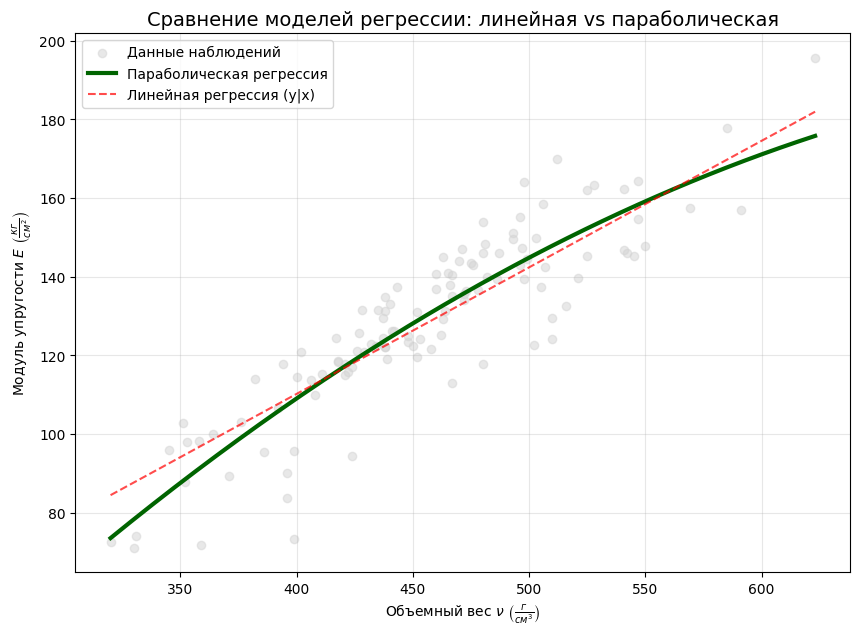

Уравнение параболы: $E = -0.000476 \cdot \nu^2 + 0.7867 \cdot \nu -129.4290$

In [56]:
beta = np.polyfit(df['nu'], df['E'], 2)

def parabolic_reg(x):
    return beta[0]*x**2 + beta[1]*x + beta[2]

plt.figure(figsize=(10, 7))
plt.scatter(df['nu'], df['E'], color='lightgray', alpha=0.5, label='Данные наблюдений')

x_range = np.linspace(df['nu'].min(), df['nu'].max(), 200)

plt.plot(x_range, parabolic_reg(x_range), color='darkgreen', linewidth=3, label='Параболическая регрессия')
plt.plot(x_range, regression_y_on_x(x_range), color='red', linestyle='--', alpha=0.7, label='Линейная регрессия (y|x)')

plt.title('Сравнение моделей регрессии: линейная vs параболическая', fontsize=14)
plt.xlabel(r'Объемный вес $\nu$ $\left(\frac{г}{см^3}\right)$')
plt.ylabel(r'Модуль упругости $E$ $\left(\frac{кг}{см^2}\right)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(Markdown(f"Уравнение параболы: $E = {beta[0]:.6f} \\cdot \\nu^2 + {beta[1]:.4f} \\cdot \\nu {beta[2]:.4f}$"))

- Визуальный анализ даёт понять, что параболическая кривая проходит близко к линии линейной регрессии.
- Параболическая модель позволяет лишь немного точнее описать поведение данных на краях выборки. 
Если брать в учёт малую разность $\eta^2 − r^2$, то усложнение модели до второго порядка не дает существенного выигрыша по сравнению с более простой линейной моделью.

### 5. Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы: a) степенная функция: $y = \beta_0 x^{\beta_1}$.

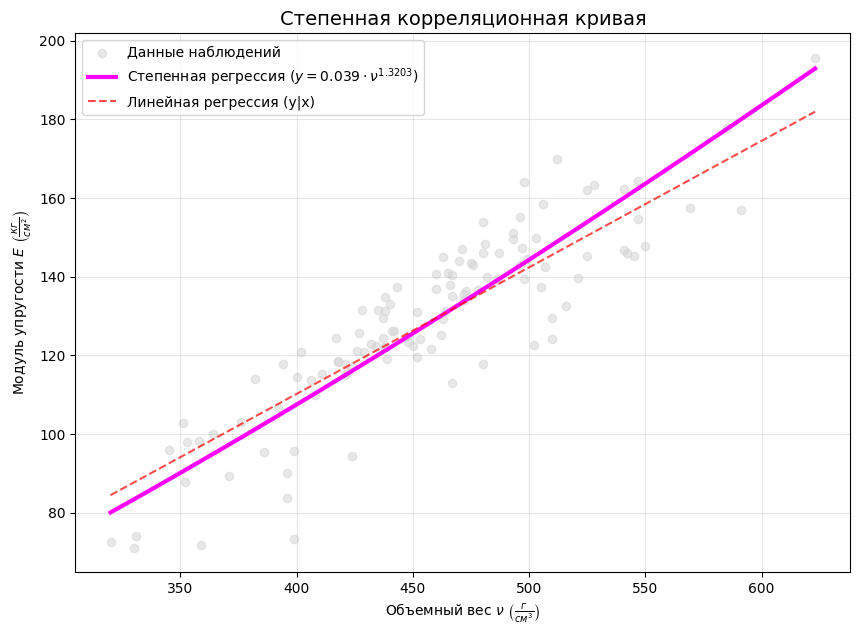

Уравнение степенной регрессии: $E = 0.03943 \cdot \nu^{1.3203}$

In [60]:
ln_x = np.log(df['nu'])
ln_y = np.log(df['E'])

coeffs = np.polyfit(ln_x, ln_y, 1)
beta1 = coeffs[0]
beta0 = np.exp(coeffs[1])

def power_reg(x):
    return beta0 * (x**beta1)

plt.figure(figsize=(10, 7))
plt.scatter(df['nu'], df['E'], color='lightgray', alpha=0.5, label='Данные наблюдений')

x_range = np.linspace(df['nu'].min(), df['nu'].max(), 200)
plt.plot(x_range, power_reg(x_range), color='magenta', linewidth=3, 
         label=rf'Степенная регрессия ($y = {beta0:.2} \cdot \nu^{{{beta1:.4f}}}$)')
plt.plot(x_range, regression_y_on_x(x_range), color='red', linestyle='--', alpha=0.7, label='Линейная регрессия (y|x)')

plt.title(r'Степенная корреляционная кривая', fontsize=14)
plt.xlabel(r'Объемный вес $\nu$ $\left(\frac{г}{см^3}\right)$')
plt.ylabel(r'Модуль упругости $E$ $\left(\frac{кг}{см^2}\right)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(Markdown(f"Уравнение степенной регрессии: $E = {beta0:.4} \\cdot \\nu^{{{beta1:.4f}}}$"))

- Визуально степенная кривая, как и параболическая, практически совпадает с прямой линейной регрессии на рассматриваемом интервале. Это еще раз указывает на то, что зависимость между характеристиками древесины близка к строго линейной.
- Степенная модель также позволяет лишь немного точнее описать поведение данных на краях выборки, однако в отличие от параболической исключает получение отрицательных значений модуля упругости при малых значениях плотности.

## Выводы

В ходе выполнения практической работы был проведен регрессионный анализ взаимосвязи между объемным весом $\nu$ и модулем упругости $E$ древесины резонансной ели.

Сравнительный анализ построенных моделей (линейной, параболической и степенной) показал их высокую сходимость и адекватность на исследуемом интервале. Вычисленные корреляционные отношения подтвердили преимущественно линейный характер связи между плотностью и упругостью ели, что позволяет использовать наиболее простую линейную модель для практических инженерных расчетов без потери точности. 
При этом степенная функция была отмечена как наиболее перспективная для целей экстраполяции благодаря её соответствию физическим границам параметров.

В процессе выполнения заданий были закреплены практические навыки применения метода наименьших квадратов и линеаризации функций для моделирования реальных экспериментальных зависимостей.